# Imports
- If your setup was done correctly, you should be able to run the following cell without any issues.

In [1]:
from hw4lib.data import (
    H4Tokenizer,
    ASRDataset,
    verify_dataloader
)
from hw4lib.model import (
    DecoderOnlyTransformer,
    EncoderDecoderTransformer
)
from hw4lib.utils import (
    create_scheduler,
    create_optimizer,
    plot_lr_schedule
)
from hw4lib.trainers import (
    ASRTrainer,
    ProgressiveTrainer
)
from torch.utils.data import DataLoader
import yaml
import gc
import torch
from torchinfo import summary
import os
import json
import wandb
import pandas as pd
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


# Implementations
- `NOTE`: All of these implementations have detailed specification, implementation details, and hints in their respective source files. Make sure to read all of them in their entirety to understand the implementation details!

## Dataset Implementation
- Implement the `ASRDataset` class in `hw4lib/data/asr_dataset.py`.
- You will have to implement parts of `__init__` and completely implement the `__len__`, `__getitem__` and `collate_fn` methods.
- Run the cell below to check your implementation.


## Config
- You can use the `config.yaml` file to set your config for your ablation study.

---
### Notes:

- Set `tokenization: token_type:` to specify your desired tokenization strategy
- You will need to set the root path to your `hw4p1_data` folder in `data: root:`. This will depend on your setup. For eg. if you are following out setup instruction:
  - `PSC`: `"/local/hw4_data/hw4p1_data"`
  - `Colab:`: `"/content/hw4_data/hw4p1_data"`
  - `Kaggle:`: `"/kaggle/input/s25-hw4-data/hw4p1_data"`
- There's extra configurations in the `optimizer` section which will only be relevant if you decide to use the `create_optimizer` function we've provided in `hw4lib/utils/create_optimizer.py`.
- `BE CAREFUL` while setting numeric values. Eg. `1e-4` will get serialized to a `str` while `1.0e-4` gets serialized to float.

In [2]:
%%writefile config.yaml

Name                      : "Zian Pan"

###### Tokenization ------------------------------------------------------------
tokenization:
  token_type                : "5k"       # [char, 1k, 5k, 10k]
  token_map :
      'char': 'hw4lib/data/tokenizer_jsons/tokenizer_char.json'
      '1k'  : 'hw4lib/data/tokenizer_jsons/tokenizer_1000.json'
      '5k'  : 'hw4lib/data/tokenizer_jsons/tokenizer_5000.json'
      '10k' : 'hw4lib/data/tokenizer_jsons/tokenizer_10000.json'

###### Dataset -----------------------------------------------------------------
data:
  root                 : "/root/autodl-tmp/hw4_data/hw4p2_data/"  # TODO: Set the root path of your data
  train_partition      : "train-clean-100"  # paired text-speech for ASR pre-training
  val_partition        : "dev-clean"        # paired text-speech for ASR pre-training
  test_partition       : "test-clean"       # paired text-speech for ASR pre-training
  subset               : 1                # Load a subset of the data (for debugging, testing, etc
  batch_size           : 32           #
  NUM_WORKERS          : 2            # Set to 0 for CPU
  norm                 : 'global_mvn' # ['global_mvn', 'cepstral', 'none']
  num_feats            : 80

  ###### SpecAugment ---------------------------------------------------------------
  specaug                   : False  # Set to True if you want to use SpecAugment
  specaug_conf:
    apply_freq_mask         : True
    freq_mask_width_range   : 5
    num_freq_mask           : 2
    apply_time_mask         : True
    time_mask_width_range   : 40
    num_time_mask           : 2

###### Network Specs -------------------------------------------------------------
model: # Encoder-Decoder Transformer (HW4P2)
  # Speech embedding parameters
  input_dim: 80              # Speech feature dimension
  time_reduction: 2          # Time dimension downsampling factor
  reduction_method: 'lstm'   # The source_embedding reduction method ['lstm', 'conv', 'both']

  # Architecture parameters
  d_model: 256           # Model dimension
  num_encoder_layers: 2  # Number of encoder layers
  num_decoder_layers: 2  # Number of decoder layers
  num_encoder_heads: 4   # Number of encoder attention heads
  num_decoder_heads: 4   # Number of decoder attention heads
  d_ff_encoder: 1024     # Feed-forward dimension for encoder
  d_ff_decoder: 1024     # Feed-forward dimension for decoder
  skip_encoder_pe: False # Whether to skip positional encoding for encoder
  skip_decoder_pe: False # Whether to skip positional encoding for decoder

  # Common parameters
  dropout: 0.0          # Dropout rate
  layer_drop_rate: 0.0  # Layer dropout rate
  weight_tying: False   # Whether to use weight tying

###### Common Training Parameters ------------------------------------------------
training:
  use_wandb                   : True   # Toggle wandb logging
  wandb_run_id                : "none" # "none" or "run_id"
  resume                      : True   # Resume an existing run (run_id != 'none')
  gradient_accumulation_steps : 1
  wandb_project               : "hw4p2-ablation" # wandb project to log to

###### Loss ----------------------------------------------------------------------
loss: # Just good ol' CrossEntropy
  label_smoothing: 0.0
  ctc_weight: 0.2

###### Optimizer -----------------------------------------------------------------
optimizer:
  name: "adamw" # Options: sgd, adam, adamw
  lr: 0.0004    # Base learning rate

  # Common parameters
  weight_decay: 0.000001

  # Parameter groups
  # You can add more param groups as you want and set their learning rates and patterns
  param_groups:
    - name: self_attn
      patterns: []  # Will match all parameters containing "ffn" and set their learning rate to 0.0002
      lr: 0.0002    # LR for self_attn
      layer_decay:
        enabled: False
        decay_rate: 0.8

    - name: ffn
      patterns: [] # Will match all parameters containing "ffn" and set their learning rate to 0.0002
      lr: 0.0002   # LR for ffn
      layer_decay:
        enabled: False
        decay_rate: 0.8

  # Layer-wise learning rates
  layer_decay:
    enabled: False
    decay_rate: 0.75

  # SGD specific parameters
  sgd:
    momentum: 0.9
    nesterov: True
    dampening: 0

  # Adam specific parameters
  adam:
    betas: [0.9, 0.999]
    eps: 1.0e-8
    amsgrad: False

  # AdamW specific parameters
  adamw:
    betas: [0.9, 0.999]
    eps: 1.0e-8
    amsgrad: False

###### Scheduler -----------------------------------------------------------------
scheduler:
  name: "cosine"  # Options: reduce_lr, cosine, cosine_warm

  # ReduceLROnPlateau specific parameters
  reduce_lr:
    mode: "min"  # Options: min, max
    factor: 0.1  # Factor to reduce learning rate by
    patience: 10  # Number of epochs with no improvement after which LR will be reduced
    threshold: 0.0001  # Threshold for measuring the new optimum
    threshold_mode: "rel"  # Options: rel, abs
    cooldown: 0  # Number of epochs to wait before resuming normal operation
    min_lr: 0.0000001  # Minimum learning rate
    eps: 1e-8  # Minimal decay applied to lr

  # CosineAnnealingLR specific parameters
  cosine:
    T_max: 15  # Maximum number of iterations
    eta_min: 0.0000001  # Minimum learning rate
    last_epoch: -1

  # CosineAnnealingWarmRestarts specific parameters
  cosine_warm:
    T_0: 10    # Number of iterations for the first restart
    T_mult: 10 # Factor increasing T_i after each restart
    eta_min: 0.0000001  # Minimum learning rate
    last_epoch: -1

  # Warmup parameters (can be used with any scheduler)
  warmup:
    enabled: True
    type: "exponential"  # Options: linear, exponential
    epochs: 5
    start_factor: 0.1
    end_factor: 1.0


Overwriting config.yaml


In [3]:
with open('config.yaml', 'r') as file:
    config = yaml.safe_load(file)

## Tokenizer

In [4]:
Tokenizer = H4Tokenizer(
    token_map  = config['tokenization']['token_map'],
    token_type = config['tokenization']['token_type']
)

                          Tokenizer Configuration (5k)                          
--------------------------------------------------------------------------------
Vocabulary size:     5000

Special Tokens:
PAD:              0
UNK:              1
MASK:             2
SOS:              3
EOS:              4
BLANK:            5

Validation Example:
--------------------------------------------------------------------------------
Input text:  [SOS]HI DEEP LEARNERS[EOS]
Tokens:      ['[SOS]', 'H', 'I', 'ĠDEEP', 'ĠLEARN', 'ERS', '[EOS]']
Token IDs:   [3, 14, 15, 1169, 2545, 214, 4]
Decoded:     [SOS]HI DEEP LEARNERS[EOS]


## Datasets

In [5]:
train_dataset = ASRDataset(
    partition=config['data']['train_partition'],
    config=config['data'],
    tokenizer=Tokenizer,
    isTrainPartition=True,
    global_stats=None  # Will compute stats from training data
)

# TODO: Get the computed global stats from training set
global_stats = None
if config['data']['norm'] == 'global_mvn':
    global_stats = (train_dataset.global_mean, train_dataset.global_std)
    print(f"Global stats computed from training set.")

val_dataset = ASRDataset(
    partition=config['data']['val_partition'],
    config=config['data'],
    tokenizer=Tokenizer,
    isTrainPartition=False,
    global_stats=global_stats
)

test_dataset = ASRDataset(
    partition=config['data']['test_partition'],
    config=config['data'],
    tokenizer=Tokenizer,
    isTrainPartition=False,
    global_stats=global_stats
)

gc.collect()

Loading data for train-clean-100 partition...


  2%|▏         | 464/28539 [00:00<00:23, 1180.37it/s]

100%|██████████| 28539/28539 [00:25<00:00, 1133.34it/s]


Global stats computed from training set.
Loading data for dev-clean partition...


100%|██████████| 2703/2703 [00:01<00:00, 2029.77it/s]


Loading data for test-clean partition...


100%|██████████| 2620/2620 [00:00<00:00, 3836.09it/s]


737

## Dataloaders

In [6]:
train_loader    = DataLoader(
    dataset     = train_dataset,
    batch_size  = config['data']['batch_size'],
    shuffle     = True,
    num_workers = config['data']['NUM_WORKERS'] if device == 'cuda' else 0,
    pin_memory  = True,
    collate_fn  = train_dataset.collate_fn
)

val_loader      = DataLoader(
    dataset     = val_dataset,
    batch_size  = config['data']['batch_size'],
    shuffle     = False,
    num_workers = config['data']['NUM_WORKERS'] if device == 'cuda' else 0,
    pin_memory  = True,
    collate_fn  = val_dataset.collate_fn
)

test_loader     = DataLoader(
    dataset     = test_dataset,
    batch_size  = config['data']['batch_size'],
    shuffle     = False,
    num_workers = config['data']['NUM_WORKERS'] if device == 'cuda' else 0,
    pin_memory  = True,
    collate_fn  = test_dataset.collate_fn
)

gc.collect()

0

### Dataloader Verification

In [7]:
verify_dataloader(train_loader)

             Dataloader Verification              
Dataloader Partition     : train-clean-100
--------------------------------------------------
Number of Batches        : 892
Batch Size               : 32
--------------------------------------------------
Checking shapes of the data...                    

Feature Shape            : [32, 2079, 80]
Shifted Transcript Shape : [32, 64]
Golden Transcript Shape  : [32, 64]
Feature Lengths Shape    : [32]
Transcript Lengths Shape : [32]
--------------------------------------------------
Max Feature Length       : 3066
Max Transcript Length    : 100
Avg. Chars per Token     : 4.24


In [8]:
verify_dataloader(val_loader)

             Dataloader Verification              
Dataloader Partition     : dev-clean
--------------------------------------------------
Number of Batches        : 85
Batch Size               : 32
--------------------------------------------------
Checking shapes of the data...                    

Feature Shape            : [32, 3676, 80]
Shifted Transcript Shape : [32, 104]
Golden Transcript Shape  : [32, 104]
Feature Lengths Shape    : [32]
Transcript Lengths Shape : [32]
--------------------------------------------------
Max Feature Length       : 4081
Max Transcript Length    : 138
Avg. Chars per Token     : 4.17


In [9]:
verify_dataloader(test_loader)

             Dataloader Verification              
Dataloader Partition     : test-clean
--------------------------------------------------
Number of Batches        : 82
Batch Size               : 32
--------------------------------------------------
Checking shapes of the data...                    

Feature Shape            : [32, 2099, 80]
Feature Lengths Shape    : [32]
--------------------------------------------------
Max Feature Length       : 4370
Max Transcript Length    : 0
Avg. Chars per Token     : 0.00


## Calculate Max Lengths
Calculating the maximum transcript length across your dataset is a crucial step when working with certain transformer models.
-  We'll use sinusoidal positional encodings that must be precomputed up to a fixed maximum length.
- This maximum length is a hyperparameter that determines:
  - How long of a sequence your model can process
  - The size of your positional encoding matrix
  - Memory requirements during training and inference
- `Requirements`: For this assignment, ensure your positional encodings can accommodate at least the longest sequence in your dataset to prevent truncation. However, you can set this value higher if you anticipate using your languagemodel to work with longer sequences in future tasks (hint: this might be useful for P2! 😉).
- `NOTE`: We'll be using the same positional encoding matrix for all sequences in your dataset. Take this into account when setting your maximum length.

In [10]:
max_feat_len       = max(train_dataset.feat_max_len, val_dataset.feat_max_len, test_dataset.feat_max_len)
max_transcript_len = max(train_dataset.text_max_len, val_dataset.text_max_len, test_dataset.text_max_len)
max_len            = max(max_feat_len, max_transcript_len)

print("="*50)
print(f"{'Max Feature Length':<30} : {max_feat_len}")
print(f"{'Max Transcript Length':<30} : {max_transcript_len}")
print(f"{'Overall Max Length':<30} : {max_len}")
print("="*50)

Max Feature Length             : 4370
Max Transcript Length          : 138
Overall Max Length             : 4370


## Wandb

In [11]:
wandb.login(key="8475199febe13b3465c7d5e4a595bba7422c14fc")

wandb: Currently logged in as: zianp (zianp-personal). Use `wandb login --relogin` to force relogin
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


True

## Training
Every time you run the trainer, it will create a new directory in the `expts` folder with the following structure:
```
expts/
    └── {run_name}/
        ├── config.yaml
        ├── model_arch.txt
        ├── checkpoints/
        │   ├── checkpoint-best-metric-model.pth
        │   └── checkpoint-last-epoch-model.pth
        ├── attn/
        │   └── {attention visualizations}
        └── text/
            └── {generated text outputs}
```


### Training Strategy 1: Cold-Start Trainer

#### Model Load (Default)

In [12]:
model_config = config['model'].copy()
model_config.update({
    'max_len': max_len,
    'num_classes': Tokenizer.vocab_size
})

model = EncoderDecoderTransformer(**model_config)

# Get some inputs from the train dataloader
for batch in train_loader:
    padded_feats, padded_shifted, padded_golden, feat_lengths, transcript_lengths = batch
    break


model_stats = summary(model, input_data=[padded_feats, padded_shifted, feat_lengths, transcript_lengths])
print(model_stats)

Layer (type:depth-idx)                        Output Shape              Param #
EncoderDecoderTransformer                     [32, 71, 5000]            --
├─SpeechEmbedding: 1-1                        [32, 1023, 256]           --
│    └─StackedBLSTMEmbedding: 2-1             [32, 1023, 256]           --
│    │    └─LSTM: 3-1                         [50786, 256]              215,040
│    │    └─MaxPool1d: 3-2                    [32, 256, 1023]           --
│    │    └─LSTM: 3-3                         [25383, 256]              395,264
│    │    └─MaxPool1d: 3-4                    [32, 256, 1023]           --
│    │    └─Linear: 3-5                       [32, 1023, 256]           65,792
│    │    └─Dropout: 3-6                      [32, 1023, 256]           --
├─PositionalEncoding: 1-2                     [32, 1023, 256]           --
├─Dropout: 1-3                                [32, 1023, 256]           --
├─ModuleList: 1-4                             --                        --
│    └

#### Initialize Trainer

If you need to reload the model from a checkpoint, you can do so by calling the `load_checkpoint` method.

```python
checkpoint_path = "path/to/checkpoint.pth"
trainer.load_checkpoint(checkpoint_path)
```


In [13]:
trainer = ASRTrainer(
    model=model,
    tokenizer=Tokenizer,
    config=config,
    run_name="p2-early-t2",
    config_file="config.yaml",
    device=device
)

Using device: cuda


wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


### Setup Optimizer and Scheduler

You can set your own optimizer and scheduler by setting the class members in the `LMTrainer` class.
Eg:
```python
trainer.optimizer = optim.AdamW(model.parameters(), lr=config['optimizer']['lr'], weight_decay=config['optimizer']['weight_decay'])
trainer.scheduler = optim.lr_scheduler.CosineAnnealingLR(trainer.optimizer, T_max=config['training']['epochs'])
```

We also provide a utility function to create your own optimizer and scheduler with the congig and some extra bells and whistles. You are free to use it or not. Do read their code and documentation to understand how it works (`hw4lib/utils/*`).


#### Setting up the optimizer

In [14]:
trainer.optimizer = create_optimizer(
    model=model,
    opt_config=config['optimizer']
)


🔧 Configuring Optimizer:
├── Type: ADAMW
├── Base LR: 0.0004
├── Weight Decay: 1e-06
├── Parameter Groups:
│   ├── Group: self_attn
│   │   ├── LR: 0.0002
│   │   └── Patterns: []
│   ├── Group: ffn
│   │   ├── LR: 0.0002
│   │   └── Patterns: []
│   └── Default Group (unmatched parameters)
└── AdamW Specific:
    ├── Betas: [0.9, 0.999]
    ├── Epsilon: 1e-08
    └── AMSGrad: False


#### Creating a test scheduler and plotting the learning rate schedule


📈 Configuring Learning Rate Scheduler:
├── Type: COSINE
├── Cosine Annealing Settings:
│   ├── T_max: 15 epochs (13380 steps)
│   └── Min LR: 1e-07
├── Warmup Settings:
│   ├── Duration: 5 epochs (4460 steps)
│   ├── Start Factor: 0.1
│   └── End Factor: 1.0


/root/miniconda3/envs/hw4/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:240: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


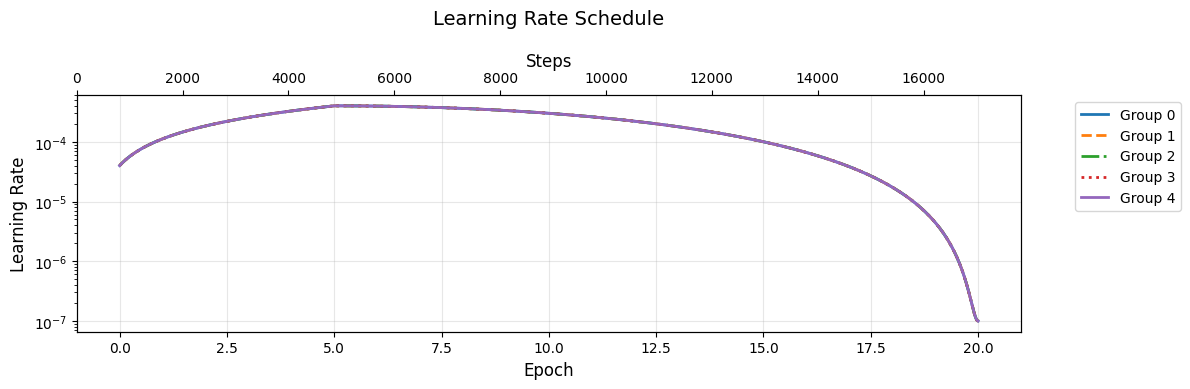

In [15]:
test_scheduler = create_scheduler(
    optimizer=trainer.optimizer,
    scheduler_config=config['scheduler'],
    train_loader=train_loader,
    gradient_accumulation_steps=config['training']['gradient_accumulation_steps']
)

plot_lr_schedule(
    scheduler=test_scheduler,
    num_epochs=20,
    train_loader=train_loader,
    gradient_accumulation_steps=config['training']['gradient_accumulation_steps']
)

#### Setting up the scheduler

In [16]:
trainer.scheduler = create_scheduler(
    optimizer=trainer.optimizer,
    scheduler_config=config['scheduler'],
    train_loader=train_loader,
    gradient_accumulation_steps=config['training']['gradient_accumulation_steps']
)


📈 Configuring Learning Rate Scheduler:
├── Type: COSINE
├── Cosine Annealing Settings:
│   ├── T_max: 15 epochs (13380 steps)
│   └── Min LR: 1e-07
├── Warmup Settings:
│   ├── Duration: 5 epochs (4460 steps)
│   ├── Start Factor: 0.1
│   └── End Factor: 1.0


#### Train
- Set your epochs

In [17]:
trainer.train(train_loader, val_loader, epochs=30)


📊 Metrics (Epoch 0):
├── TRAIN:
│   ├── ce_loss: 6.7974
│   ├── ctc_loss: 12.4341
│   ├── joint_loss: 9.2842
│   ├── perplexity_char: 4.9734
│   └── perplexity_token: 895.5035
└── VAL:
    ├── cer: 204.6494
    ├── wer: 329.5538
    └── word_dist: 165.6125
└── TRAINING:
    └── learning_rate: 0.000112


wandb: WARNING Saving files without folders. If you want to preserve subdirectories pass base_path to wandb.save, i.e. wandb.save("/mnt/folder/file.h5", base_path="/mnt")



📊 Metrics (Epoch 1):
├── TRAIN:
│   ├── ce_loss: 5.9171
│   ├── ctc_loss: 6.8689
│   ├── joint_loss: 7.2908
│   ├── perplexity_char: 4.0404
│   └── perplexity_token: 371.3179
└── VAL:
    ├── cer: 73.0306
    ├── wer: 96.8072
    └── word_dist: 59.1063
└── TRAINING:
    └── learning_rate: 0.000184



📊 Metrics (Epoch 2):
├── TRAIN:
│   ├── ce_loss: 5.4286
│   ├── ctc_loss: 6.7212
│   ├── joint_loss: 6.7728
│   ├── perplexity_char: 3.6005
│   └── perplexity_token: 227.8226
└── VAL:
    ├── cer: 72.7757
    ├── wer: 104.5436
    └── word_dist: 58.8937
└── TRAINING:
    └── learning_rate: 0.000256



📊 Metrics (Epoch 3):
├── TRAIN:
│   ├── ce_loss: 5.1151
│   ├── ctc_loss: 6.6109
│   ├── joint_loss: 6.4373
│   ├── perplexity_char: 3.3438
│   └── perplexity_token: 166.5165
└── VAL:
    ├── cer: 75.9654
    ├── wer: 106.4675
    └── word_dist: 61.4813
└── TRAINING:
    └── learning_rate: 0.000328


[Training ASR]:  30%|███       | 270/892 [01:04<02:25,  4.27it/s, acc_step=1/1, ce_loss=4.8722, ctc_loss=6.2806, joint_loss=6.1283, perplexity=130.6030]

KeyboardInterrupt: 

#### Inference


In [ ]:
# Define the recognition config: Greedy search
recognition_config = {
    'num_batches': None,
    'temperature': 1.0,
    'repeat_penalty': 1.0,
    'lm_weight': None,
    'lm_model': None,
    'beam_width': 1, # Beam width of 1 reverts to greedy
}

# Recognize with the shallow fusion config
config_name = "test"
print(f"Evaluating with {config_name} config")
results = trainer.recognize(test_loader, recognition_config, config_name=config_name, max_length=max_transcript_len)


# Calculate metrics on full batch
generated = [r['generated'] for r in results]
results_df = pd.DataFrame(
    {
        'id': range(len(generated)),
        'transcription': generated
    }
)

# Cleanup (Will end wandb run)
trainer.cleanup()

Evaluating with test config


learning_rate,▃▄▅▇███▇▇▆▆▅▄▃▃▂▂▁▁▁▁▁▂▂▃
train/ce_loss,█▇▆▅▅▅▄▄▄▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁
train/ctc_loss,█▃▇▃▄▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
train/joint_loss,█▆▆▅▅▄▄▄▃▃▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁
train/perplexity_char,█▆▅▅▄▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
train/perplexity_token,█▄▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/cer,▁▆▁▁█▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/wer,▂▅▁▁█▁▁▂▁▁▁▁▂▂▁▁▁▁▁▁▁▁▁▁▁
val/word_dist,▁▆▁▁█▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
learning_rate,0.0001
train/ce_loss,2.94899


## Submit to Kaggle

### Authenticate Kaggle
In order to use the Kaggle’s public API, you must first authenticate using an API token. Go to the 'Account' tab of your user profile and select 'Create New Token'. This will trigger the download of kaggle.json, a file containing your API credentials.
- `TODO`: Set your kaggle username and api key here based on the API credentials listed in the kaggle.json




In [ ]:
import os
os.environ["KAGGLE_USERNAME"] = "your_kaggle_username_here"
os.environ["KAGGLE_KEY"] = "your_kaggle_api_key_here"

In [ ]:
results_df.head()

,id,transcription
0,0,HE HOPED THERE WOULD BE STUPID IN HER APARTMEN...
1,1,STAFFIDONITY HIS BELTUM
2,2,AFTER EARLY NIGHTFALLLY YELLOW THE YELLOW LAME...
3,3,HOW BERYET EVENING O'CLOCK IN YOUR MIND
4,4,NOT BUT DAMP FRESH N'S WAIT ON YOU ON YOU COUL...


### Submit

In [ ]:
results_df.to_csv("results.csv", index=False)
# !kaggle competitions submit -c 11785-s25-hw4p2-asr -f results.csv -m "My Submission"